In [2]:
#Load stock data
import pandas as pd

stock_df = pd.read_csv("../data/raw/META.csv")
stock_df.isnull().sum() #Check for and handle missing values
stock_df.dropna(inplace=True)
stock_df.dtypes
stock_df.head()

,Date,Close,High,Low,Open,Volume
0,2012-05-18,37.995762,44.724282,37.767172,41.792356,573576400
1,2012-05-21,33.821495,36.435382,32.797807,36.306177,168192700
2,2012-05-22,30.810066,33.384198,30.750434,32.410203,101786600
3,2012-05-23,31.803938,32.300874,31.167860,31.177799,73600000
4,2012-05-24,32.827625,33.006523,31.575347,32.748117,50237200


In [3]:
#Convert Date
stock_df["Date"] = pd.to_datetime(stock_df["Date"])
stock_df = stock_df.sort_values("Date")
stock_df.head()

,Date,Close,High,Low,Open,Volume
0,2012-05-18,37.995762,44.724282,37.767172,41.792356,573576400
1,2012-05-21,33.821495,36.435382,32.797807,36.306177,168192700
2,2012-05-22,30.810066,33.384198,30.750434,32.410203,101786600
3,2012-05-23,31.803938,32.300874,31.167860,31.177799,73600000
4,2012-05-24,32.827625,33.006523,31.575347,32.748117,50237200


In [4]:
#Set price column
price = stock_df["Close"]
print(price.head())

0    37.995762
1    33.821495
2    30.810066
3    31.803938
4    32.827625
Name: Close, dtype: float64


In [5]:
#Moving Averages (SMA & EMA)
from ta.trend import SMAIndicator, EMAIndicator

stock_df["SMA_20"] = SMAIndicator(price, window=20).sma_indicator()
stock_df["EMA_20"] = EMAIndicator(price, window=20).ema_indicator()
stock_df.head()

,Date,Close,High,Low,Open,Volume,SMA_20,EMA_20
0,2012-05-18,37.995762,44.724282,37.767172,41.792356,573576400,NaN,NaN
1,2012-05-21,33.821495,36.435382,32.797807,36.306177,168192700,NaN,NaN
2,2012-05-22,30.810066,33.384198,30.750434,32.410203,101786600,NaN,NaN
3,2012-05-23,31.803938,32.300874,31.167860,31.177799,73600000,NaN,NaN
4,2012-05-24,32.827625,33.006523,31.575347,32.748117,50237200,NaN,NaN


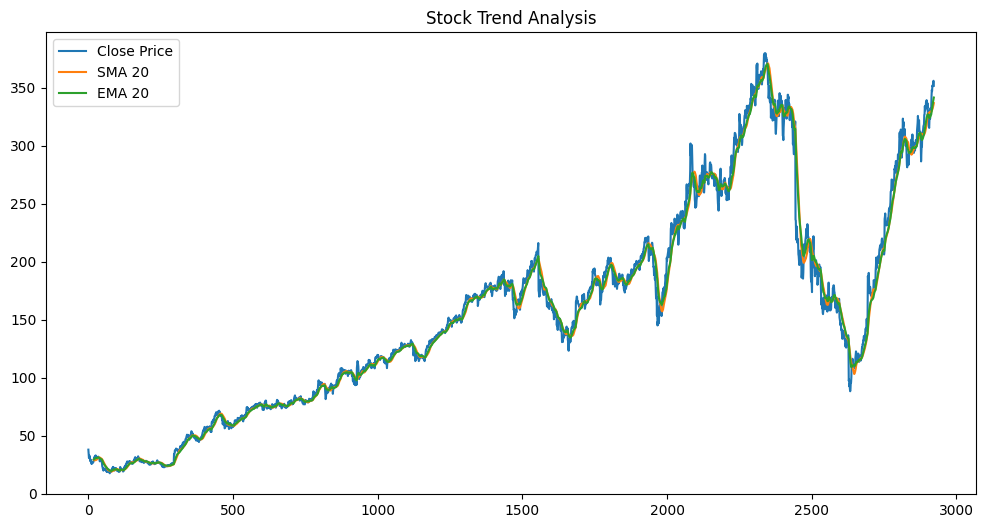

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(stock_df["Close"], label="Close Price")
plt.plot(stock_df["SMA_20"], label="SMA 20")
plt.plot(stock_df["EMA_20"], label="EMA 20")

plt.legend()
plt.title("Stock Trend Analysis")
plt.show()

EMA reacts faster to recent price changes compared to SMA, making it more responsive to short-term market movements.

In [7]:
#RSI (momentum indicator)
from ta.momentum import RSIIndicator

stock_df["RSI"] = RSIIndicator(price, window=14).rsi()
stock_df.head()

,Date,Close,High,Low,Open,Volume,SMA_20,EMA_20,RSI
0,2012-05-18,37.995762,44.724282,37.767172,41.792356,573576400,NaN,NaN,NaN
1,2012-05-21,33.821495,36.435382,32.797807,36.306177,168192700,NaN,NaN,NaN
2,2012-05-22,30.810066,33.384198,30.750434,32.410203,101786600,NaN,NaN,NaN
3,2012-05-23,31.803938,32.300874,31.167860,31.177799,73600000,NaN,NaN,NaN
4,2012-05-24,32.827625,33.006523,31.575347,32.748117,50237200,NaN,NaN,NaN


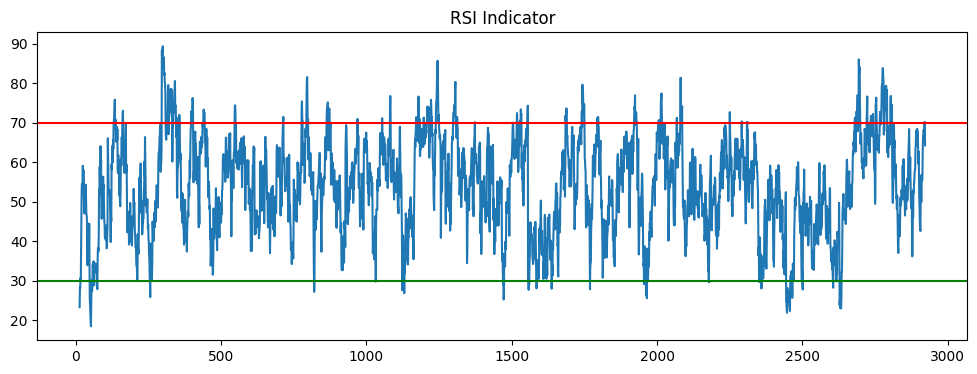

In [8]:
plt.figure(figsize=(12,4))
plt.plot(stock_df["RSI"])
plt.axhline(70, color='red')
plt.axhline(30, color='green')
plt.title("RSI Indicator")
plt.show()

RSI values above 70 indicate overbought conditions, while values below 30 suggest oversold conditions.

In [9]:
#MACD (trend signal)
from ta.trend import MACD

macd = MACD(price)

stock_df["MACD"] = macd.macd()
stock_df["MACD_signal"] = macd.macd_signal()
stock_df.head()

,Date,Close,High,Low,Open,Volume,SMA_20,EMA_20,RSI,MACD,MACD_signal
0,2012-05-18,37.995762,44.724282,37.767172,41.792356,573576400,NaN,NaN,NaN,NaN,NaN
1,2012-05-21,33.821495,36.435382,32.797807,36.306177,168192700,NaN,NaN,NaN,NaN,NaN
2,2012-05-22,30.810066,33.384198,30.750434,32.410203,101786600,NaN,NaN,NaN,NaN,NaN
3,2012-05-23,31.803938,32.300874,31.167860,31.177799,73600000,NaN,NaN,NaN,NaN,NaN
4,2012-05-24,32.827625,33.006523,31.575347,32.748117,50237200,NaN,NaN,NaN,NaN,NaN


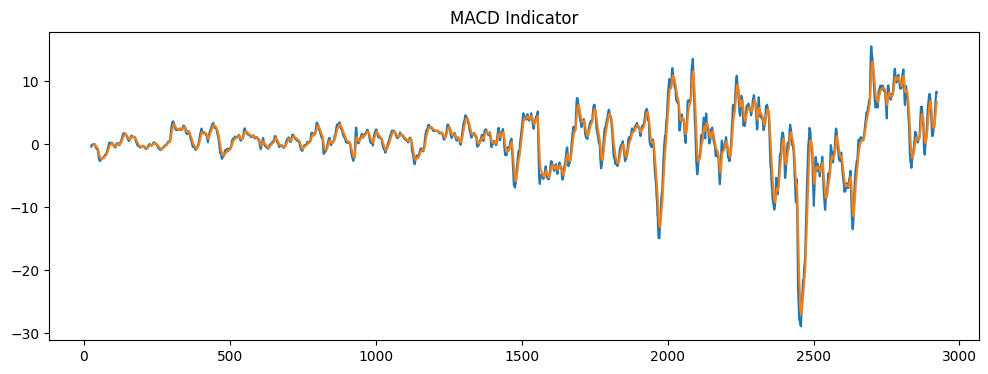

In [10]:
#MACD
plt.figure(figsize=(12,4))
plt.plot(stock_df["MACD"], label="MACD")
plt.plot(stock_df["MACD_signal"], label="Signal Line")
plt.title("MACD Indicator")
plt.show()

MACD crossing above the signal line may indicate bullish momentum, while crossing below may indicate bearish momentum.

Volatility: 0.025279908739443274
Average Daily Return: 0.0010818741576271995
Sharpe Ratio: 0.04122608307990322


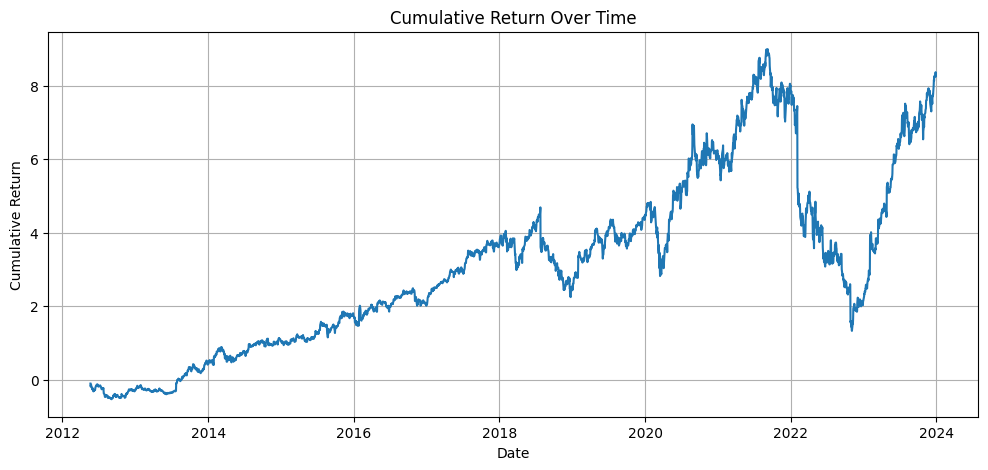

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Daily Returns
# =========================
stock_df["Daily_Return"] = stock_df["Close"].pct_change()

# =========================
# 2. Volatility
# =========================
volatility = stock_df["Daily_Return"].std()

# =========================
# 3. Average Return
# =========================
avg_return = stock_df["Daily_Return"].mean()

# =========================
# 4. Cumulative Return
# =========================
stock_df["Cumulative_Return"] = (1 + stock_df["Daily_Return"]).cumprod() - 1

# =========================
# 5. Sharpe Ratio
# =========================
risk_free_rate = 0.01 / 252

sharpe_ratio = (
    (stock_df["Daily_Return"].mean() - risk_free_rate)
    / stock_df["Daily_Return"].std()
)

# =========================
# PRINT METRICS
# =========================
print("Volatility:", volatility)
print("Average Daily Return:", avg_return)
print("Sharpe Ratio:", sharpe_ratio)

# =========================
# 6. Cumulative Return Plot
# =========================
plt.figure(figsize=(12,5))

plt.plot(stock_df["Date"], stock_df["Cumulative_Return"])

plt.title("Cumulative Return Over Time")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")

plt.grid(True)
plt.show()